# Holt-Winters para el consumo electrico horario

## Objetivos
- Separar train, validation y test en orden cronologico.
- Ajustar tendencia y estacionalidad aditivas con periodo diario de 24 horas.
- Comparar Holt-Winters con Seasonal Naive y revisar los errores fuera de muestra.

## Datos y alcance
La variable objetivo es `Consumption`, agregada por hora. Los huecos se completan con la ultima observacion disponible; los valores iniciales que no tienen historia se descartan. El pronostico de cada bloque es de origen fijo: no incorpora observaciones reales de ese mismo bloque a medida que avanza el horizonte.

In [1]:
# Librerias para el modelo Holt-Winters
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

In [ ]:
# Construimos una ruta reproducible al archivo fuente compartido
from ml_course.data import get_data_path

csv_path = get_data_path("electricity_consumption_and_production.csv", category="external")
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontro el archivo: {csv_path.resolve()}')

# Cargamos datos originales (consumo + produccion por fuente)
raw = pd.read_csv(csv_path)

# Convertimos DateTime a formato fecha y lo usamos como indice temporal
raw['DateTime'] = pd.to_datetime(raw['DateTime'])
raw = raw.sort_values('DateTime').set_index('DateTime')

# Resumen rapido para entender tamano, columnas y posibles faltantes
print('Shape del dataset original:', raw.shape)
print('Columnas disponibles:', list(raw.columns))
print('Valores nulos por columna:')
print(raw.isna().sum())

# Visualizamos primeras filas del dataset completo
display(raw.head())

Shape del dataset original: (62810, 9)
Columnas disponibles: ['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
Valores nulos por columna:
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [3]:
# Analisis de variables candidatas para explicar Consumption
# Evaluamos correlacion lineal de cada variable original contra el target.

candidate_cols = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'Consumption'
]

corr_with_target = raw[candidate_cols].corr(numeric_only=True)['Consumption'] \
    .drop('Consumption') \
    .sort_values(key=np.abs, ascending=False)

print('Correlacion (ordenada por magnitud absoluta) con Consumption:')
display(corr_with_target.to_frame('corr_vs_consumption'))

# Breve conclusion automatica de candidatas
strong_candidates = corr_with_target[np.abs(corr_with_target) >= 0.25].index.tolist()
moderate_candidates = corr_with_target[(np.abs(corr_with_target) >= 0.10) & (np.abs(corr_with_target) < 0.25)].index.tolist()

print('Candidatas fuertes (|corr| >= 0.25):', strong_candidates)
print('Candidatas moderadas (0.10 <= |corr| < 0.25):', moderate_candidates)

Correlacion (ordenada por magnitud absoluta) con Consumption:


,corr_vs_consumption
Production,0.690823
Oil and Gas,0.499442
Coal,0.472298
Biomass,0.400475
Hydroelectric,0.358047
Nuclear,0.161838
Wind,0.102026
Solar,-0.048037


Candidatas fuertes (|corr| >= 0.25): ['Production', 'Oil and Gas', 'Coal', 'Biomass', 'Hydroelectric']
Candidatas moderadas (0.10 <= |corr| < 0.25): ['Nuclear', 'Wind']


## Estimacion y evaluacion del modelo Holt-Winters

Se ajusta un modelo `ExponentialSmoothing` con tendencia aditiva y estacionalidad aditiva diaria (`24` observaciones por ciclo). La evaluacion respeta el orden temporal: primero se pronostica validation y luego test mediante reentrenamiento con train + validation.

In [ ]:
# Serie horaria de Consumption
series = (
    raw[['Consumption']]
    .sort_index()
    .groupby(level=0)['Consumption']
    .mean()
    .astype(float)
    .asfreq('h')
)
series = series.ffill().dropna()

seasonal_periods = 24
n_rows = len(series)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

train_series = series.iloc[:train_end]
val_series = series.iloc[train_end:val_end]
test_series = series.iloc[val_end:]

# Ajuste inicial y pronostico del bloque de validation
holt_winters_train = ExponentialSmoothing(
    train_series,
    trend='add',
    seasonal='add',
    seasonal_periods=seasonal_periods,
    damped_trend=True,
    initialization_method='estimated',
).fit(optimized=True, use_brute=True)

pred_val_hw = holt_winters_train.forecast(len(val_series))

# Reentrenamiento con train + validation antes de pronosticar test
train_validation_series = pd.concat([train_series, val_series])
holt_winters_final = ExponentialSmoothing(
    train_validation_series,
    trend='add',
    seasonal='add',
    seasonal_periods=seasonal_periods,
    damped_trend=True,
    initialization_method='estimated',
).fit(optimized=True, use_brute=True)

pred_test_hw = holt_winters_final.forecast(len(test_series))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    nonzero = y_true != 0
    if not np.any(nonzero):
        return float('nan')
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def seasonal_naive(history, forecast_index, seasonal_period=24):
    if len(history) < seasonal_period:
        raise ValueError('La historia debe incluir al menos un ciclo diario completo.')
    last_cycle = history.iloc[-seasonal_period:].to_numpy()
    return pd.Series(np.resize(last_cycle, len(forecast_index)), index=forecast_index)

def forecast_metrics(actual, forecast):
    return {
        'MAE': mean_absolute_error(actual, forecast),
        'RMSE': np.sqrt(mean_squared_error(actual, forecast)),
        'R2': r2_score(actual, forecast),
        'MAPE_%': mape(actual, forecast),
    }

naive_val_hw = seasonal_naive(train_series, val_series.index, seasonal_periods)
naive_test_hw = seasonal_naive(train_validation_series, test_series.index, seasonal_periods)
holt_winters_results = pd.DataFrame([
    {'modelo': 'Seasonal Naive (24 h)', 'split': 'validation', **forecast_metrics(val_series, naive_val_hw)},
    {'modelo': 'Holt-Winters', 'split': 'validation', **forecast_metrics(val_series, pred_val_hw)},
    {'modelo': 'Seasonal Naive (24 h)', 'split': 'test', **forecast_metrics(test_series, naive_test_hw)},
    {'modelo': 'Holt-Winters', 'split': 'test', **forecast_metrics(test_series, pred_test_hw)},
]).sort_values(['split', 'RMSE']).reset_index(drop=True)

print(f'Observaciones horarias despues de agregar duplicados: {len(series)}')
print('Configuracion Holt-Winters:')
print({
    'trend': 'add',
    'seasonal': 'add',
    'seasonal_periods': seasonal_periods,
    'damped_trend': True,
})
print('Los huecos se rellenan hacia adelante; los valores iniciales sin historia se descartan.')
print('\nComparacion con Seasonal Naive de 24 horas:')
display(holt_winters_results.round(4))

Observaciones horarias despues de agregar duplicados: 63120
Configuracion Holt-Winters:
{'trend': 'add', 'seasonal': 'add', 'seasonal_periods': 24, 'damped_trend': True}

Metricas Holt-Winters:


,MAE,RMSE,R2,MAPE_%
split,,,,
validation,1014.2586,1286.8011,-0.6708,18.1801
test,1057.9351,1374.4699,-0.5862,19.2095


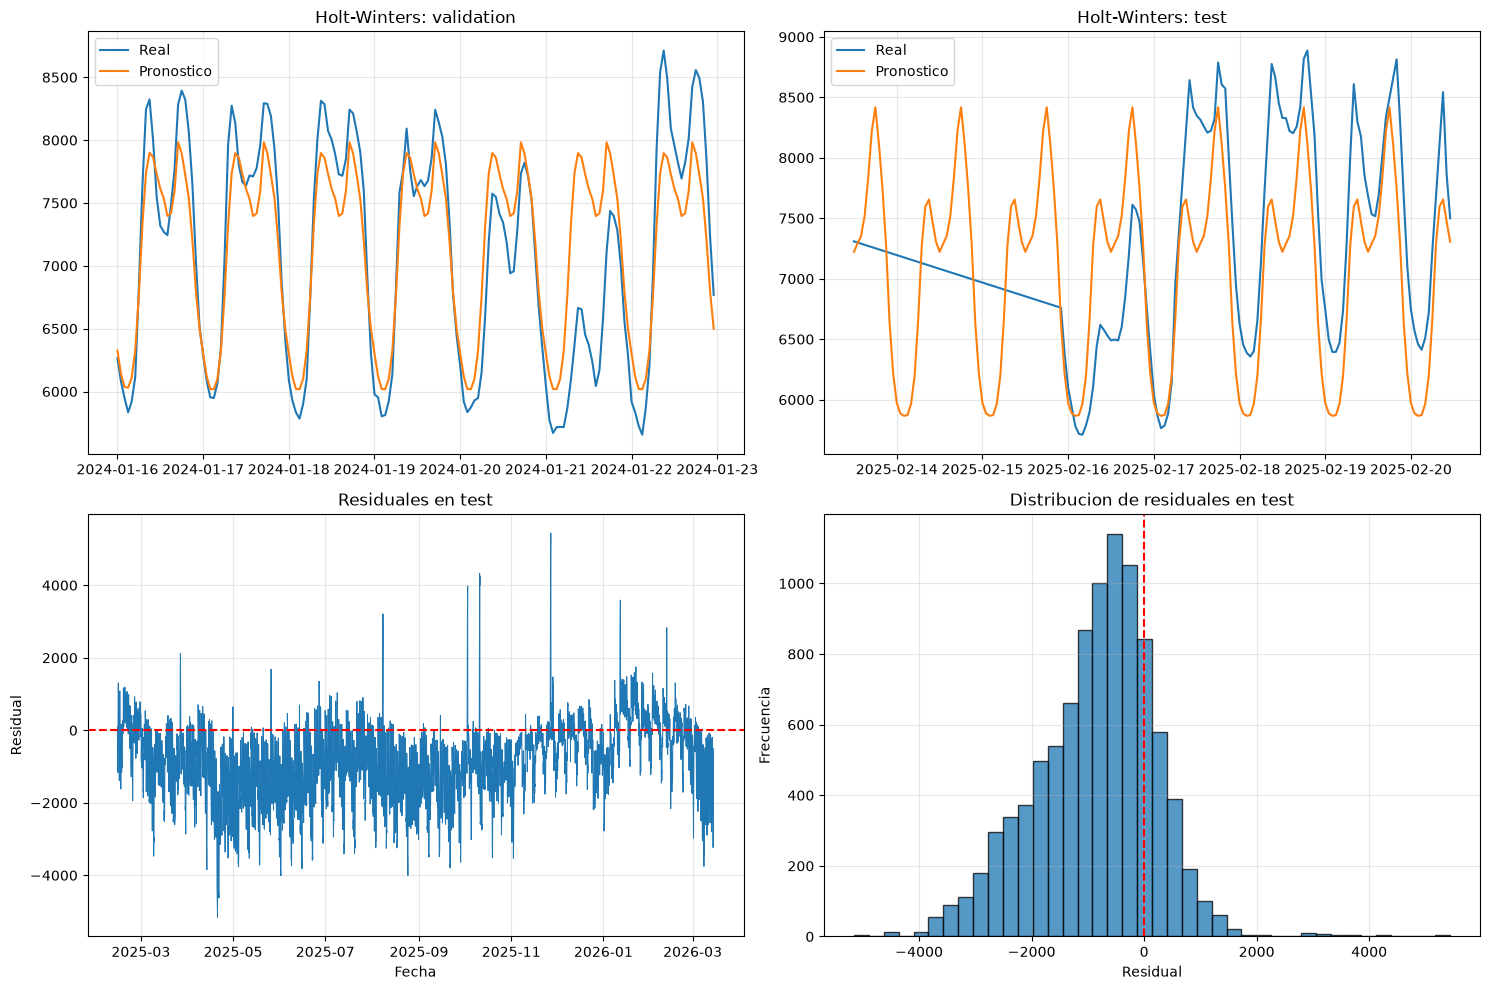

In [5]:
# Diagnostico visual de Holt-Winters en validation y test
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Validation: primeras observaciones del bloque
validation_window = min(24 * 7, len(val_series))
axes[0, 0].plot(val_series.index[:validation_window], val_series.iloc[:validation_window], label='Real')
axes[0, 0].plot(pred_val_hw.index[:validation_window], pred_val_hw.iloc[:validation_window], label='Pronostico')
axes[0, 0].set_title('Holt-Winters: validation')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Test: primeras observaciones del bloque
axes[0, 1].plot(test_series.index[:validation_window], test_series.iloc[:validation_window], label='Real')
axes[0, 1].plot(pred_test_hw.index[:validation_window], pred_test_hw.iloc[:validation_window], label='Pronostico')
axes[0, 1].set_title('Holt-Winters: test')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Residuales de test
test_residuals_hw = test_series.to_numpy() - pred_test_hw.to_numpy()
axes[1, 0].plot(test_series.index, test_residuals_hw, linewidth=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title('Residuales en test')
axes[1, 0].set_xlabel('Fecha')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].grid(alpha=0.3)

# Distribucion de residuales
axes[1, 1].hist(test_residuals_hw, bins=40, edgecolor='black', alpha=0.75)
axes[1, 1].axvline(0, color='red', linestyle='--')
axes[1, 1].set_title('Distribucion de residuales en test')
axes[1, 1].set_xlabel('Residual')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretacion y limites
Compara el RMSE de ambos metodos en validation antes de considerar test. El Seasonal Naive repite el ultimo ciclo diario observado; Holt-Winters representa nivel, tendencia amortiguada y patron estacional. Un mejor error en un bloque no garantiza estabilidad en otras temporadas. La imputacion forward-fill evita mirar hacia adelante, pero mantiene el ultimo valor durante los huecos y puede suavizar cambios abruptos.

## Ejercicios
1. Cambia `damped_trend` y compara los errores de validation; deja test intacto hasta elegir.
2. Prueba una estacionalidad semanal y explica si el cambio mejora un ciclo que tenga sentido para estos datos.
3. Grafica los errores de test por hora del dia y describe donde falla cada metodo.

## Referencias
- [Statsmodels: ExponentialSmoothing](https://www.statsmodels.org/stable/generated/statsmodels.tsa.holtwinters.ExponentialSmoothing.html)
- Hyndman y Athanasopoulos, *Forecasting: Principles and Practice*, seccion de metodos de suavizado exponencial: https://otexts.com/fpp3/expsmooth.html